In [1]:
# Instalar LightGBM directamente desde el notebook
!pip install lightgbm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración estética
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

# 1. Carga de datos
input_path = '../data/Filtered.pkl' 

print("📥 Cargando dataset para modelado de Regresión...")
if os.path.exists(input_path):
    df = pd.read_pickle(input_path)
    print(f"✅ Dataset cargado correctamente: {df.shape[0]} filas y {df.shape[1]} columnas.")
else:
    print(f"❌ Error: No se encontró el archivo en {input_path}")

display(df.head(3))

📥 Cargando dataset para modelado de Regresión...
✅ Dataset cargado correctamente: 114567 filas y 16 columnas.


,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        114567 non-null  object 
 1   is_delayed                      114567 non-null  int64  
 2   actual_delivery_days            114567 non-null  float64
 3   estimated_delivery_margin_days  114567 non-null  int64  
 4   purchase_month                  114567 non-null  int32  
 5   purchase_day_of_week            114567 non-null  int32  
 6   product_weight_g                114567 non-null  float64
 7   product_volume_cm3              114567 non-null  float64
 8   product_category_name_english   114567 non-null  object 
 9   customer_zip_code_prefix        114567 non-null  int64  
 10  seller_zip_code_prefix          114567 non-null  float64
 11  is_same_state                   114567 non-null  int64  
 12  customer_state_num_pr

In [3]:
# 1. Selección de variables
# Eliminamos 'order_id', las coordenadas y 'is_delayed' (para no hacer trampa).
features_to_drop = ['order_id', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng', 'is_delayed']

# La "X" (features) pierde el target, la "y" es nuestro tiempo real en días
X = df.drop(columns=features_to_drop + ['actual_delivery_days'], errors='ignore')
y = df['actual_delivery_days']

# 2. Definición de variables categóricas
cat_cols = [
    'product_category_name_english', 
    'customer_state_num_pred', 
    'seller_state_num_pred',
    'purchase_month', 
    'purchase_day_of_week',
    'is_same_state'
]

for col in cat_cols:
    X[col] = X[col].astype('category')

print(f"✅ Codificación completada. Variables predictoras: {X.shape[1]}")
print(f"Target: actual_delivery_days (Regresión continua)")

✅ Codificación completada. Variables predictoras: 13
Target: actual_delivery_days (Regresión continua)


📊 Análisis de los Días de Entrega (Target):
 - Media de entrega: 11.99 días
 - Mediana (El 50% llega antes de): 10.00 días
 - Desviación Estándar: 9.41 días


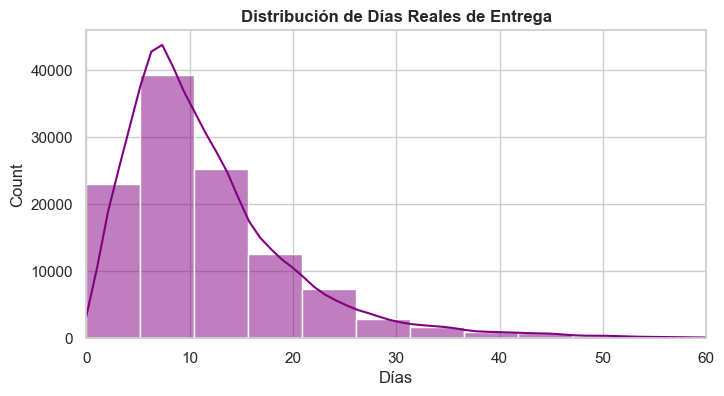

In [4]:
print(f"📊 Análisis de los Días de Entrega (Target):")
print(f" - Media de entrega: {y.mean():.2f} días")
print(f" - Mediana (El 50% llega antes de): {y.median():.2f} días")
print(f" - Desviación Estándar: {y.std():.2f} días")

plt.figure(figsize=(8, 4))
sns.histplot(y, bins=40, kde=True, color='purple')
plt.title('Distribución de Días Reales de Entrega', fontweight='bold')
plt.xlabel('Días')
plt.xlim(0, 60) # Cortamos la cola extrema para ver mejor
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# 1. Separamos un 15% para el Test final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# 2. Separamos otro 15% para Validación
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.15, random_state=42
)

print("📈 División de datos finalizada para Regresión:")
print(f" - Entrenamiento: {X_train.shape[0]} registros")
print(f" - Validación: {X_val.shape[0]} registros")
print(f" - Prueba: {X_test.shape[0]} registros")

📈 División de datos finalizada para Regresión:
 - Entrenamiento: 82773 registros
 - Validación: 14608 registros
 - Prueba: 17186 registros


In [6]:
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

print("🚀 Iniciando modelo LightGBM para REGRESIÓN...")

# 1. Definición de Hiperparámetros (Sin pesos de clases)
lgbm_params = {
    'objective': 'regression',          # 🚨 CLAVE: Cambiamos a problema de regresión
    'metric': 'rmse',                   # 🚨 CLAVE: Root Mean Squared Error
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'n_estimators': 1500,               
    'num_leaves': 63,                   
    'max_depth': 8,                     
    'min_child_samples': 50,            
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

# 2. Instanciar el modelo (Usamos LGBMRegressor en lugar de Classifier)
model_lgb = lgb.LGBMRegressor(**lgbm_params)

print("⏳ Entrenando...")

# 3. Entrenamiento con Early Stopping
model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Entrenamiento', 'Validacion'],
    categorical_feature=cat_cols,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, first_metric_only=True, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✅ Entrenamiento finalizado.")
print(f"🌲 Número de árboles creados óptimamente: {model_lgb.best_iteration_}")

🚀 Iniciando modelo LightGBM para REGRESIÓN...
⏳ Entrenando...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1758
[LightGBM] [Info] Number of data points in the train set: 82773, number of used features: 13
[LightGBM] [Info] Start training from score 11.999287
Training until validation scores don't improve for 100 rounds
[50]	Entrenamiento's rmse: 7.4556	Validacion's rmse: 7.57281
[100]	Entrenamiento's rmse: 7.20429	Validacion's rmse: 7.4368
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

💾 1. GUARDANDO EL MODELO...
✅ Modelo guardado en: ../models/lgbm_regression_model.pkl

🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...
--------------------------------------------------
🔹 MAE (Error Absoluto Medio): 4.20 días (Margen de error promedio)
🔹 RMSE (Error Cuadrático Medio): 7.28 días (Penaliza errores graves)
🔹 R-cuadrado (R2): 0.4225 (El % de variabilidad que tu modelo explica, 1.0 es perfecto)
--------------------------------------------------


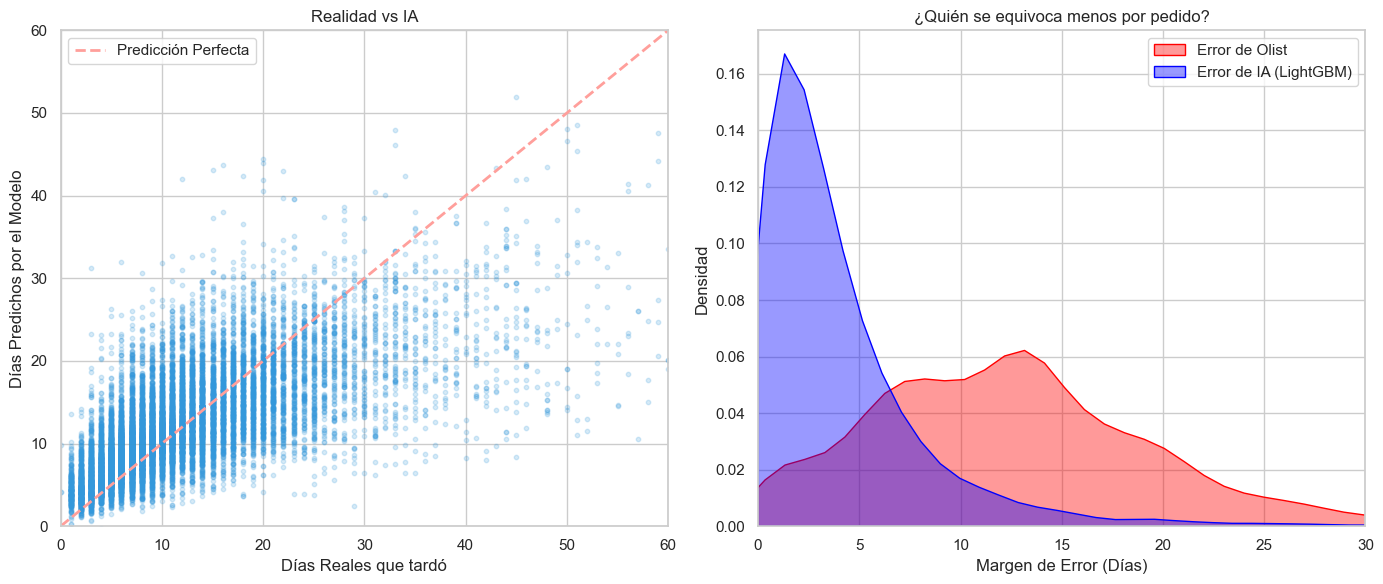

In [7]:
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("💾 1. GUARDANDO EL MODELO...")
os.makedirs('../models', exist_ok=True)
model_path = '../models/lgbm_regression_model.pkl'
joblib.dump(model_lgb, model_path)
print(f"✅ Modelo guardado en: {model_path}\n")

print("🎯 2. EVALUANDO EN EL CONJUNTO DE TEST...")
# Predicción de DÍAS (Ya no son 0 o 1, son números reales continuos)
y_pred = model_lgb.predict(X_test)

# Calcular métricas de regresión
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 50)
print(f"🔹 MAE (Error Absoluto Medio): {mae:.2f} días (Margen de error promedio)")
print(f"🔹 RMSE (Error Cuadrático Medio): {rmse:.2f} días (Penaliza errores graves)")
print(f"🔹 R-cuadrado (R2): {r2:.4f} (El % de variabilidad que tu modelo explica, 1.0 es perfecto)")
print("-" * 50)

# 3. VISUALIZACIÓN: Predicción vs Realidad
plt.figure(figsize=(14, 6))

# Subplot 1: Dispersión de Real vs Predicho
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.2, color='#3498db', s=10)
# Línea ideal (donde la predicción es exactamente igual a la realidad)
plt.plot([y_test.min(), 60], [y_test.min(), 60], 'r--', lw=2, label="Predicción Perfecta")
plt.xlabel("Días Reales que tardó")
plt.ylabel("Días Predichos por el Modelo")
plt.title("Realidad vs IA")
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.legend()

# Subplot 2: Comparativa de Olist vs Nuestro Modelo
# (Asumimos que 'estimated_delivery_margin_days' sigue en X_test)
if 'estimated_delivery_margin_days' in X_test.columns:
    plt.subplot(1, 2, 2)
    # Error de Olist
    error_olist = np.abs(y_test - X_test['estimated_delivery_margin_days'])
    # Error de nuestro modelo ML
    error_ml = np.abs(y_test - y_pred)
    
    sns.kdeplot(error_olist, fill=True, color="red", label="Error de Olist", alpha=0.4)
    sns.kdeplot(error_ml, fill=True, color="blue", label="Error de IA (LightGBM)", alpha=0.4)
    plt.title('¿Quién se equivoca menos por pedido?')
    plt.xlabel('Margen de Error (Días)')
    plt.ylabel('Densidad')
    plt.xlim(0, 30)
    plt.legend()

plt.tight_layout()
plt.show()